In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("sephora_cleaned(1).csv")

In [ ]:
len(df["product"].unique())

153

In [ ]:
df.columns

Index(['product', 'brand', 'loves_count', 'avg_rating', 'reviews', 'size',
       'ingredients', 'price', 'limited_edition', 'new', 'online_only',
       'sephora_exclusive', 'highlights', 'review_rating', 'is_recommended',
       'helpfulness', 'total_feedback_count', 'total_neg_feedback_count',
       'total_pos_feedback_count', 'review_text', 'review_title', 'skin_tone',
       'skin_type'],
      dtype='object')

In [ ]:
df['brand'].unique()

array(['Algenist', 'Alpha-H', 'alpyn beauty', 'Augustinus Bader',
       'BeautyBio', 'belif', 'Benefit Cosmetics', 'Biossance',
       'Bobbi Brown', 'Caudalie', 'Clarins', 'CLINIQUE',
       'Community Sixty-Six', 'DAMDAM', 'Dermalogica', 'Dior',
       'Dr. Barbara Sturm', 'Dr. Brandt Skincare',
       'Dr. Dennis Gross Skincare', 'Dr. Zenovia Skincare',
       'Drunk Elephant', 'Estée Lauder', 'FaceGym', 'Farmacy',
       'Fenty Skin', 'First Aid Beauty', 'fresh', 'Glossier',
       'Glow Recipe', 'goop', 'Herbivore', 'Hourglass', 'Hyper Skin',
       'iNNBEAUTY PROJECT', 'innisfree', 'IT Cosmetics', 'JLo Beauty',
       'Josie Maran', 'Kate Somerville', "Kiehl's Since 1851",
       'KORA Organics', 'KORRES', 'Lancôme', 'LANEIGE', 'MACRENE actives',
       'Mario Badescu', 'MILK MAKEUP', 'Moon Juice', 'Murad',
       'Naturally Serious', 'OLEHENRIKSEN', 'Origins', "Paula's Choice",
       'Peace Out', 'Peter Thomas Roth', 'RANAVAT', 'REN Clean Skincare',
       'ROSE Ingleton MD', 

In [ ]:
len(df)

87832

In [ ]:
# =========================================
# Attribute Lexicon + Lift + Sentiment (no extra installs)
# End-to-end: builds BOTH brand-overall and brand×skin_type results
# =========================================

import re, math
import numpy as np
import pandas as pd
from collections import defaultdict, Counter

# ---------- Column names in your df (do not rename) ----------
BRAND_COL      = "brand"
TITLE_COL      = "review_title"
TEXT_COL       = "review_text"
RATING_COL     = "review_rating"
SKIN_COL       = "skin_type"
HELP_POS_COL   = "total_pos_feedback_count"
HELP_NEG_COL   = "total_neg_feedback_count"
HELP_TOTAL_COL = "total_feedback_count"

# ---------- Sentiment config ----------
POS_STAR = 4       # >=4 : weak positive prior at sentence level
NEG_STAR = 2       # <=2 : weak negative prior at sentence level
PRIOR_WEIGHT = 0.4 # strength of the star prior (0..1)
NEGATORS = {"no","not","never","without","isn't","wasn't","don't","doesn't","didn't","won't","can't"}

POS_LEX = {
    "hydrating","moisturizing","gentle","soothing","soft","smooth","non-drying","non drying","nondrying",
    "brightening","effective","works","nice","pleasant","refreshing","clean","cleans","cleaned",
    "glowing","radiant","calming","lightweight","balanced","non-greasy","nongreasy","nonsticky",
    "love","loved","great","amazing","perfect","favorite","reliable"
}
NEG_LEX = {
    "drying","tight","stripping","stripped","burning","burns","stinging","stings","irritated","irritating",
    "redness","breakout","breakouts","broke","breaks","acne","pimples","residue","film","greasy","oily",
    "sticky","heavy","strong","overpowering","harsh","itchy","tingle","tingling",
    "worse","bad","awful","hate","hated","disappointing","useless","waste","rash"
}

# ---------- Thresholds / output ----------
MIN_BRAND_SEGS = 40      # require at least this many attribute-bearing segments per slice
TOP_K = 5                 # top 5 positive and top 5 negative per slice

# ---------- Sentence splitting / text cleaning ----------
CONTRAST = {"but","however","although","though","yet","except"}
STOP = set("""
a an the and or of to in on for with without into out up down is are was were be been being this that it its
very really just quite bit lot lots much many more most less least too than rather so such as same similar
i me my mine you your yours they them their we our ours he she her his hers one ones two three four five
""".split())

def norm_str(x):
    if pd.isna(x): return ""
    return str(x).strip().lower()

def norm_str_or_none(x):
    if pd.isna(x): return None
    s = str(x).strip()
    return s.lower() if s else None

def helpful_weight(row: pd.Series) -> float:
    pos = float(row.get(HELP_POS_COL, 0) or 0)
    neg = float(row.get(HELP_NEG_COL, 0) or 0)
    tot = float(row.get(HELP_TOTAL_COL, 0) or 0)
    w = 1.0 + (pos - neg)
    if np.isnan(w) or w < 0:
        w = 1.0 + max(tot, 0)
    return max(w, 1.0)

def build_text(row: pd.Series) -> str:
    t1 = norm_str(row.get(TITLE_COL))
    t2 = norm_str(row.get(TEXT_COL))
    txt = (t1 + ". " + t2).strip()
    txt = re.sub(r"http\S+|www\.\S+|\S+@\S+", " ", txt)
    txt = re.sub(r"[^a-z0-9\s\-\']", " ", txt)
    txt = re.sub(r"\s+", " ", txt).strip()
    return txt

def split_sentences(text: str):
    parts = re.split(r"[\.!\?:;]\s+", text)
    units = []
    for p in parts:
        p = p.strip()
        if not p:
            continue
        toks = p.split()
        last = 0
        for i, tok in enumerate(toks):
            if tok in CONTRAST:
                seg = " ".join(toks[last:i]).strip()
                if seg: units.append(seg)
                last = i+1
        tail = " ".join(toks[last:]).strip()
        if tail: units.append(tail)
    out = []
    for s in units:
        s = s[:600]
        if len(s) >= 8: out.append(s)
    return out[:12]

def tokens_list(s: str):
    return [w for w in s.split() if w not in STOP]

def has_negation(tokens, idx, window=3):
    start = max(0, idx-window)
    return any(t in NEGATORS for t in tokens[start:idx])

def sentence_sentiment(seg: str, star: float) -> int:
    toks = tokens_list(seg)
    score = 0.0
    if pd.notna(star):
        if star >= POS_STAR: score += PRIOR_WEIGHT
        elif star <= NEG_STAR: score -= PRIOR_WEIGHT
    for i, w in enumerate(toks):
        if w in POS_LEX:
            score += -1.0 if has_negation(toks, i) else 1.0
        if w in NEG_LEX:
            score +=  1.0 if has_negation(toks, i) else -1.0
    if score > 0.15: return 1
    if score < -0.15: return -1
    return 0

# ---------- Attribute Lexicon (UPDATED & COMPILED) ----------
attr_patterns_raw = {
    # --- Cleansing performance / efficacy ---
    "deep cleansing": [
        r"\bdeep(ly)?\s+(clean|cleanse|cleansing)\b",
        r"\b(thorough(ly)?|really)\s+clean(s|ed|ing)?\b",
        r"\bsqueaky\s+clean\b"
    ],
    "removes makeup": [
        r"\b(remove|removed|removes|takes?)\s+(off|away)\s+(make[\s\-]?up|mascara|eyeliner|foundation)\b",
        r"\b(make[\s\-]?up|mascara|eyeliner|foundation)\s+(came|comes)\s+off\b",
        r"\b(excellent|great)\s+make[\s\-]?up\s+remover\b"
    ],
    "removes waterproof makeup": [
        r"\b(remove|removes|removed|takes?)\s+(off|away)\s+waterproof\b",
        r"\bwaterproof\s+(make[\s\-]?up|mascara)\s+(came|comes)\s+off\b"
    ],
    "removes sunscreen": [
        r"\b(remove|removed|removes|takes?)\s+(off|away)\s+(spf|sunscreen)\b",
        r"\b(spf|sunscreen)\s+(came|comes)\s+off\b"
    ],
    "pore cleansing": [
        r"\bclean(s|ed|ing)?\s+out\s+pores?\b",
        r"\b(unclog|decongest)s?\s+pores?\b",
        r"\bpores?\s*(feel|look)\s*(clean|clearer)\b"
    ],
    "blackheads": [
        r"\bblack\s*heads?\b",
        r"\breduced?\s+black\s*heads?\b"
    ],
    "acne control/clarifying": [
        r"\b(clarif(y|ies|ying)|clarifying)\b",
        r"\bhelps?\s+(with\s+)?(acne|break[\s\-]?outs?)\b",
        r"\bkeeps?\s+(acne|break[\s\-]?outs?)\s+(away|at bay)\b"
    ],

    # --- After-feel / moisture balance ---
    "non-stripping/gentle": [
        r"\b(non[\-\s]?stripp?ing|not\s+stripp?ing)\b",
        r"\bgentle\b",
        r"\bnot\s+(harsh|rough)\b",
        r"\bno\s+tight(ening)?\b"
    ],
    "non-drying": [
        r"\b(non[\-\s]?drying|not\s+drying|didn['’]t\s+dry(\s+me)?\s+out)\b",
        r"\bdoes\s+not\s+dry\s+(me|skin)\s+out\b"
    ],
    "hydrating/moisturizing": [
        r"\b(hydrat\w+|adds?\s+moisture|moisturiz\w+|plump(ing)?)\b",
        r"\bleaves?\s+(skin\s+)?(hydrated|moisturized|plump)\b"
    ],
    "tight/stripping": [
        r"\b(leaves?|left)\s+(my\s+)?skin\s+tight\b",
        r"\bstripp?ing\b",
        r"\btight(ening)?\b"
    ],
    "leaves residue/film": [
        r"\bleaves?\s+(a\s+)?(residue|film)\b",
        r"\b(residue|filmy?)\s+(left|after)\b",
        r"\bdoesn['’]t\s+rinse\s+clean\b"
    ],
    "soft/smooth after": [
        r"\bleaves?\s+(skin\s+)?(soft|softer|smooth|smoother)\b",
        r"\bskin\s+(feels|felt)\s+(soft|smooth)\b"
    ],
    "greasy/oily feel": [
        r"\b(greasy|oily|oilier|oiliness|slick)\b",
        r"\bleaves?\s+(a\s+)?(greasy|oily)\s+feel\b"
    ],
    "sticky/tacky": [
        r"\b(sticky|tacky)\b",
        r"\bleaves?\s+(a\s+)?(sticky|tacky)\s+film\b"
    ],

    # --- Sensory: fragrance & texture ---
    "fragrance - strong": [
        r"\b(strong|overpowering|too\s+(strong|much))\s+(scent|smell|fragrance)\b",
        r"\bfragrance\s+is\s+(too|very)\s+strong\b"
    ],
    "fragrance - pleasant": [
        r"\b(pleasant|nice|light|fresh|subtle)\s+(scent|smell|fragrance)\b"
    ],
    "fragrance-free/unscented": [
        r"\b(fragrance[-\s]?free|unscented|no\s+fragrance)\b"
    ],
    "texture/foam/lather": [
        r"\b(lather|foam|foamy|creamy|cream\s*to\s*foam|gel|balm|milky|milk|oil(y)?|jelly|mousse)\b"
    ],
    "lathers well": [
        r"\b(good|rich|nice)\s+lather\b",
        r"\blathers?\s+(well|nicely)\b"
    ],
    "does not lather": [
        r"\b(no|doesn['’]t|does\s+not)\s+lather\b",
        r"\blather\s+is\s+(weak|minimal)\b"
    ],

    # --- Reactions / sensitivity ---
    "irritation/redness": [
        r"\b(irritat\w+|redness|itch(y)?|rash|dermatitis)\b",
        r"\bmade\s+(me\s+)?(red|rashy|itchy)\b"
    ],
    "sting/burn": [
        r"\b(sting(s|ing)?|burn(s|ing)?)\b",
        r"\bmade\s+(my\s+)?(skin|face|eyes?)\s+(sting|burn)\b"
    ],
    "stings eyes": [
        r"\b(sting(s|ing)?|burn(s|ing)?)\s+(in|my)\s+eyes?\b",
        r"\bmade\s+my\s+eyes?\s+(sting|burn)\b"
    ],
    "does not sting eyes": [
        r"\b(does\s+not|doesn['’]t)\s+(sting|burn)\s+my\s+eyes?\b",
        r"\b(gentle|safe)\s+on\s+eyes?\b"
    ],
    "breakouts/acne": [
        r"\b(break[\s\-]?outs?|broke\s+out|caused?\s+acne|new\s+pimples?)\b"
    ],
    "non-comedogenic": [
        r"\b(non[\-\s]?comedogenic|does\s+not\s+clog\s+pores?)\b"
    ],
    "clogs pores": [
        r"\b(clog(s|ged)?\s+pores?)\b"
    ],

    # --- Targets / results ---
    "brightening/radiance": [
        r"\b(brighten\w+|radiance|glow(ing)?)\b",
        r"\bgives?\s+(a\s+)?(glow|radiance)\b"
    ],
    "even tone": [
        r"\b(even(s|ed)?\s+(out\s+)?(tone|complexion))\b",
        r"\breduce(s|d)?\s+dark\s+spots?\b"
    ],
    "calming/soothing": [
        r"\b(calm(s|ed|ing)?|sooth(es|ed|ing))\b",
        r"\breduces?\s+redness\b"
    ],
    "pore minimizing": [
        r"\b(pore(s)?\s*(look|appear)\s*(smaller|minimi[sz]ed?))\b",
        r"\bminimi[sz]e\s+pores\b"
    ],
    "oil control": [
        r"\b(control(s|led)?\s+oil|reduced?\s+oiliness|less\s+oily)\b",
        r"\bhelp(s|ed)?\s+with\s+oil\s+control\b"
    ],
    "exfoliating feel": [
        r"\b(exfoliat(ing|es|ed)|microbeads?|scrub)\b",
        r"\bpolish(es|ed|ing)\b"
    ],

    # --- Usability & value ---
    "rinses clean": [
        r"\brinses?\s+clean\b",
        r"\bno\s+residue\s+after\b"
    ],
    "hard to rinse": [
        r"\bhard\s+to\s+rinse\b",
        r"\bdoesn['’]t\s+rinse\s+off\s+easily\b"
    ],
    "value/price": [
        r"\b(value|worth\s+(the\s+)?money|overpriced|too\s+expensive|price(y)?)\b",
        r"\bgood\s+value\b"
    ],
    "packaging/pump": [
        r"\b(packaging|pump|dispenser|cap|leaks?)\b",
        r"\bpump\s+(stops|stopped|broke|breaks)\b"
    ],
    "leaks/spills": [
        r"\b(leaks?|spills?|leaky)\b"
    ],
    "size/amount": [
        r"\b(size|travel\s+(friendly|size)|a\s+little\s+(goes?|go)\s+a\s+long\s+way)\b"
    ],
    "lasts long": [
        r"\b(last(s|ed)?\s+a\s+long\s+time|long[-\s]?lasting)\b"
    ],

    # --- Claims / formulation notes ---
    "ph-balanced": [
        r"\bpH[\-\s]?(balanced|balancing)\b",
        r"\bbalanced\s+pH\b"
    ],
    "dermatologist-tested": [
        r"\bdermatologist\s+(tested|recommended)\b"
    ],
    "cruelty-free/vegan": [
        r"\b(cruelty[\-\s]?free|vegan)\b"
    ],
    "fragrance-free claim": [
        r"\b(fragrance[\-\s]?free)\b"
    ]
}
attr_patterns = {
    k: [re.compile(pat, flags=re.IGNORECASE) for pat in pats]
    for k, pats in attr_patterns_raw.items()
}

def find_attributes(text: str):
    found = []
    for attr, regs in attr_patterns.items():
        for rg in regs:
            if rg.search(text):
                found.append(attr)
                break
    return found

# ---------- Build sentence-level dataset ----------
df_reviews = df.copy()
df_reviews["_text"] = df_reviews.apply(build_text, axis=1)
df_reviews = df_reviews[df_reviews["_text"].str.len() > 0].reset_index(drop=True)

seg_rows = []
for _, row in df_reviews.iterrows():
    if pd.isna(row.get(BRAND_COL)):
        continue
    brand = str(row[BRAND_COL]).strip()
    skin = norm_str_or_none(row.get(SKIN_COL))
    rating = float(row.get(RATING_COL)) if pd.notna(row.get(RATING_COL)) else np.nan
    weight = helpful_weight(row)

    for seg in split_sentences(row["_text"]):
        attrs = find_attributes(seg)
        if not attrs:
            continue
        pol = sentence_sentiment(seg, rating)  # +1 / -1 / 0
        seg_rows.append({
            "brand": brand,
            "skin_type": skin,
            "segment": seg,
            "attributes": list(set(attrs)),  # unique per sentence
            "polarity": int(pol),
            "weight": float(weight)
        })

segs = pd.DataFrame(seg_rows)
print("Segments kept:", len(segs))
if segs.empty:
    display(segs)
    raise SystemExit("No attribute mentions found. Consider expanding attr_patterns.")

# ---------- Global (background) frequencies for lift ----------
attr_global = Counter()
total_global = 0.0
for attrs, w in zip(segs["attributes"], segs["weight"]):
    for a in set(attrs):
        attr_global[a] += w
        total_global += w
P_attr = {a: (attr_global[a] / max(total_global, 1.0)) for a in attr_global}

# ---------- Aggregate BOTH brand-overall and brand×skin ----------
def add_hit(G, a, seg, pol, w):
    if pol > 0:
        G["attr_pos"][a] += w
        if len(G["ex_pos"][a]) < 2:
            G["ex_pos"][a].append(seg)
    elif pol < 0:
        G["attr_neg"][a] += w
        if len(G["ex_neg"][a]) < 2:
            G["ex_neg"][a].append(seg)
    else:
        G["attr_neu"][a] += w

grouped = defaultdict(lambda: {
    "attr_pos": Counter(), "attr_neg": Counter(), "attr_neu": Counter(),
    "total_w": 0.0,
    "ex_pos": defaultdict(list), "ex_neg": defaultdict(list)
})

for _, r in segs.iterrows():
    brand = r["brand"]
    skin  = r["skin_type"] if (isinstance(r["skin_type"], str) and r["skin_type"].strip()) else None
    w     = float(r["weight"])
    a_set = set(r["attributes"])

    keys = [(brand, "__overall__")]
    if skin is not None:
        keys.append((brand, skin))

    for key in keys:
        G = grouped[key]
        for a in a_set:
            add_hit(G, a, r["segment"], r["polarity"], w)
        G["total_w"] += w

# ---------- Scoring: Lift + Sentiment ----------
def safe_prob(x, total):
    return x / max(total, 1.0)

rows = []
for (brand, slice_key), G in grouped.items():
    total_w = G["total_w"]
    if total_w < MIN_BRAND_SEGS:
        continue

    attrs = set(G["attr_pos"].keys()) | set(G["attr_neg"].keys()) | set(G["attr_neu"].keys())
    for a in attrs:
        c_pos = G["attr_pos"].get(a, 0.0)
        c_neg = G["attr_neg"].get(a, 0.0)
        c_neu = G["attr_neu"].get(a, 0.0)
        c_tot = c_pos + c_neg + c_neu
        if c_tot < 2.0:
            continue

        p_attr_brand  = safe_prob(c_tot, total_w)
        p_attr_global = max(P_attr.get(a, 1e-12), 1e-12)
        log2lift = math.log2(p_attr_brand / p_attr_global)

        pos_share = c_pos / c_tot
        neg_share = c_neg / c_tot
        net_sent  = (c_pos - c_neg) / c_tot

        pos_score = log2lift * pos_share
        neg_score = log2lift * neg_share

        rows.append({
            "brand": brand,
            "skin_type": None if slice_key == "__overall__" else slice_key,
            "attribute": a,
            "count_pos": c_pos,
            "count_neg": c_neg,
            "count_total": c_tot,
            "pos_share": pos_share,
            "neg_share": neg_share,
            "net_sent": net_sent,
            "log2lift": log2lift,
            "pos_score": pos_score,
            "neg_score": neg_score,
            "ex_pos": " | ".join(G["ex_pos"].get(a, [])[:1]),
            "ex_neg": " | ".join(G["ex_neg"].get(a, [])[:1]),
        })

brand_attr = pd.DataFrame(rows)

if brand_attr.empty:
    print("No brand slices passed thresholds. Lower MIN_BRAND_SEGS or expand patterns.")
    top_overall = pd.DataFrame()
    top_by_skin = pd.DataFrame()
else:
    out_rows = []
    for (b, s), sub in brand_attr.groupby(["brand","skin_type"]):
        pos_top = (sub.sort_values(["pos_score","net_sent","log2lift"], ascending=[False, False, False])
                      .head(TOP_K).copy())
        pos_top["polarity"] = "positive"

        neg_top = (sub.sort_values(["neg_score","net_sent","log2lift"], ascending=[False, True, False])
                      .head(TOP_K).copy())
        neg_top["polarity"] = "negative"

        out_rows.append(pd.concat([pos_top, neg_top], axis=0))

    top_cards = pd.concat(out_rows, axis=0).reset_index(drop=True)
    top_cards = top_cards[[
        "brand","skin_type","polarity","attribute",
        "log2lift","pos_share","neg_share","net_sent",
        "count_pos","count_neg","count_total","ex_pos","ex_neg"
    ]].sort_values(["brand","skin_type","polarity","log2lift"], ascending=[True, True, False, False]).reset_index(drop=True)

    top_overall = top_cards[top_cards["skin_type"].isna()].copy()
    top_by_skin = top_cards[~top_cards["skin_type"].isna()].copy()

    display(top_overall.head(40))
    display(top_by_skin.head(40))
    print(f"Overall brand cards: {top_overall['brand'].nunique()} brands")
    print(f"Brand-skin slices: {top_by_skin[['brand','skin_type']].drop_duplicates().shape[0]} pairs")

# Optional quick checks:
# print("rows overall:", len(top_overall), "rows by-skin:", len(top_by_skin))
# size_per_slice = ( (pd.concat([top_overall.assign(skin_type=np.nan), top_by_skin], ignore_index=True))
#                    .groupby(["brand","skin_type","polarity"], dropna=False).size().unstack("polarity", fill_value=0) )
# display(size_per_slice.head(10))


Segments kept: 84814


,brand,skin_type,polarity,attribute,log2lift,pos_share,neg_share,net_sent,count_pos,count_neg,count_total,ex_pos,ex_neg


,brand,skin_type,polarity,attribute,log2lift,pos_share,neg_share,net_sent,count_pos,count_neg,count_total,ex_pos,ex_neg
0,Algenist,combination,positive,hydrating/moisturizing,1.860178,0.797710,0.190840,0.606870,209.0,50.0,262.0,the go-to anti-aging cleanser i absolutely lov...,garbage literally feels like spreading liguidy...
1,Algenist,combination,positive,acne control/clarifying,1.812161,1.000000,0.000000,1.000000,13.0,0.0,13.0,using as part of a 4 step process i have been ...,
2,Algenist,combination,positive,non-drying,1.697734,1.000000,0.000000,1.000000,19.0,0.0,19.0,what i love about this is how non-drying it is...,
3,Algenist,combination,positive,texture/foam/lather,1.360309,0.651911,0.334004,0.317907,324.0,166.0,497.0,not a huge fan of this cleanser i ve been usin...,seems to feel like oil and my face does not fe...
4,Algenist,combination,positive,brightening/radiance,0.888632,1.000000,0.000000,1.000000,40.0,0.0,40.0,my second cleanser takes care of any left over...,
5,Algenist,combination,negative,hard to rinse,3.185216,0.000000,1.000000,-1.000000,0.0,2.0,2.0,,hard to rinse off i don t like the smell and i...
6,Algenist,combination,negative,cruelty-free/vegan,1.704090,0.000000,1.000000,-1.000000,0.0,12.0,12.0,,in a way i m glad they did i came here to try ...
7,Algenist,combination,negative,leaves residue/film,1.147875,0.166667,0.833333,-0.666667,2.0,10.0,12.0,making remover with skincare benefits i tried ...,is difficult to rinse off and leaves residue s...
8,Algenist,combination,negative,tight/stripping,1.101162,0.510204,0.489796,0.020408,50.0,48.0,98.0,i have to let the world know how amazing these...,i have combination skin and am prone to a litt...
9,Algenist,combination,negative,fragrance - strong,0.558576,0.000000,1.000000,-1.000000,0.0,5.0,5.0,,too gentle when i use this product it has a st...


Overall brand cards: 0 brands
Brand-skin slices: 251 pairs


In [ ]:
top_by_skin.to_csv('top_by_skin.csv', index=False)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# If you DON'T already have top_by_skin in memory, uncomment and point to your file:
# top_by_skin = pd.read_excel("top_by_skin.xls")  # or .csv if that's what you saved

# Make sure expected columns exist
required_cols = {"brand","skin_type","attribute","log2lift","net_sent","pos_share","neg_share","count_total"}
missing = required_cols - set(top_by_skin.columns)
assert not missing, f"Missing columns in top_by_skin: {missing}"

# Define which attributes count as "efficacy" for the positioning plot
EFFICACY_ATTRS = {
    "deep cleansing","removes makeup","removes waterproof makeup","removes sunscreen",
    "pore cleansing","blackheads","acne control/clarifying","pore minimizing","oil control","rinses clean"
}


In [ ]:
def brand_positioning_by_skin(top_by_skin: pd.DataFrame, skin: str, efficacy_attrs=EFFICACY_ATTRS,
                              min_brands=3, label_top_k=25):
    """Scatter of brands for one skin_type: x=mean log2lift (efficacy), y=mean net_sent (efficacy)."""
    sub = top_by_skin.copy()
    sub = sub[sub["skin_type"].astype(str).str.lower()==skin.lower()] if pd.notna(skin) else sub[sub["skin_type"].isna()]
    sub = sub[sub["attribute"].isin(efficacy_attrs)]
    if sub.empty:
        print(f"No efficacy attributes found for skin_type={skin!r}.")
        return

    agg = (sub.groupby("brand", as_index=False)
              .agg(x_mean_log2lift=("log2lift","mean"),
                   y_mean_net_sent=("net_sent","mean"),
                   size_mentions=("count_total","sum")))

    if len(agg) < min_brands:
        print(f"Only {len(agg)} brands available for skin_type={skin!r}. Showing anyway.")

    # --- FIXED size scaling ---
    max_val = max(float(agg["size_mentions"].max()), 1.0)  # avoid division by 0 and .clip() on float
    sizes = 100.0 * (agg["size_mentions"] / max_val).fillna(0.1)

    # Plot
    plt.figure(figsize=(9,7))
    ax = plt.gca()
    ax.scatter(agg["x_mean_log2lift"], agg["y_mean_net_sent"], s=sizes)

    # Axes & grids
    ax.axvline(0, linestyle="--")
    ax.axhline(0, linestyle="--")
    ax.set_xlabel("Avg log2-lift on efficacy attributes")
    ax.set_ylabel("Avg net sentiment on efficacy attributes")
    ax.set_title(f"Brand positioning — skin_type = {skin}")

    # Label the most “important” points (by size_mentions then x+y)
    lab = (agg.sort_values(["size_mentions","x_mean_log2lift","y_mean_net_sent"], ascending=[False,False,False])
              .head(label_top_k))
    for _, r in lab.iterrows():
        ax.text(r["x_mean_log2lift"], r["y_mean_net_sent"], r["brand"], fontsize=9, ha="left", va="bottom")

    plt.show()
    display(agg.sort_values(["x_mean_log2lift","y_mean_net_sent"], ascending=False).head(20))


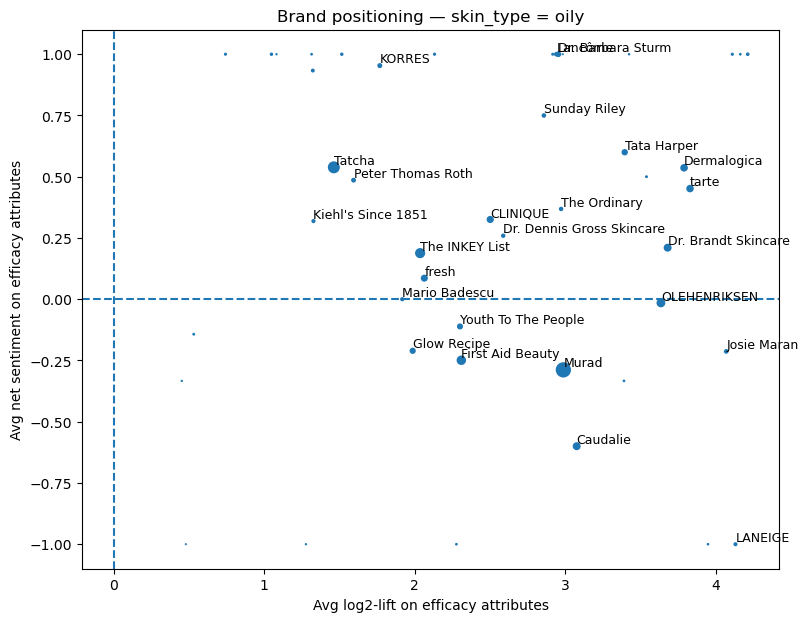

,brand,x_mean_log2lift,y_mean_net_sent,size_mentions
27,Origins,4.212502,1.000000,17.0
32,SK-II,4.163247,1.000000,6.0
21,LANEIGE,4.131273,-1.000000,24.0
0,Algenist,4.110186,1.000000,11.0
17,Josie Maran,4.069814,-0.212963,37.0
16,IT Cosmetics,3.948792,-1.000000,5.0
45,tarte,3.829407,0.451613,124.0
7,Dermalogica,3.789715,0.536410,128.0
10,Dr. Brandt Skincare,3.680534,0.210237,143.0
26,OLEHENRIKSEN,3.636034,-0.015003,185.0


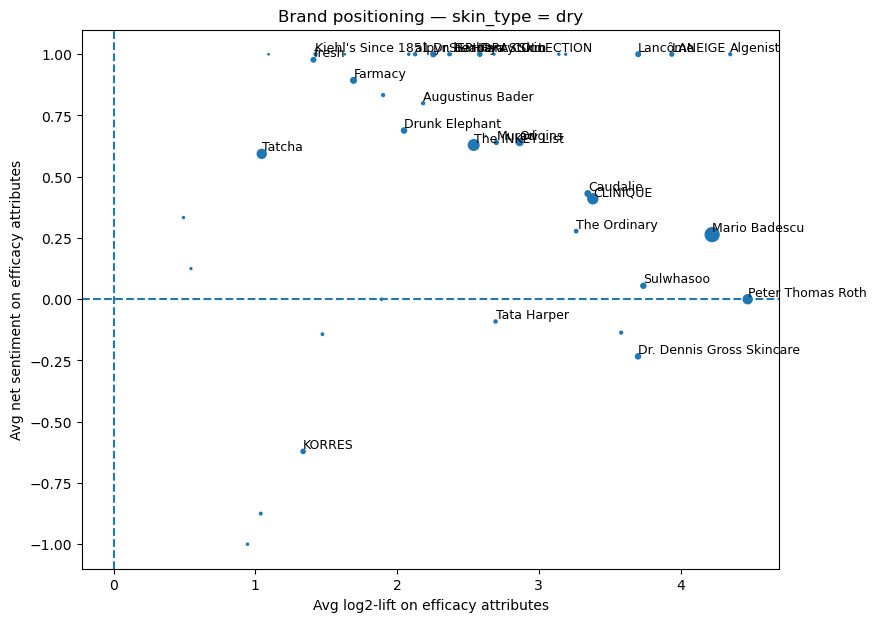

,brand,x_mean_log2lift,y_mean_net_sent,size_mentions
25,Peter Thomas Roth,4.473871,0.000000,185.0
0,Algenist,4.350900,1.000000,19.0
21,Mario Badescu,4.222868,0.263636,440.0
19,LANEIGE,3.938628,1.000000,33.0
29,Sulwhasoo,3.737681,0.054815,58.0
20,Lancôme,3.701414,1.000000,48.0
8,Dr. Dennis Gross Skincare,3.700000,-0.233333,60.0
31,Sunday Riley,3.581328,-0.136364,19.0
2,CLINIQUE,3.381266,0.409790,227.0
3,Caudalie,3.345821,0.431373,70.0


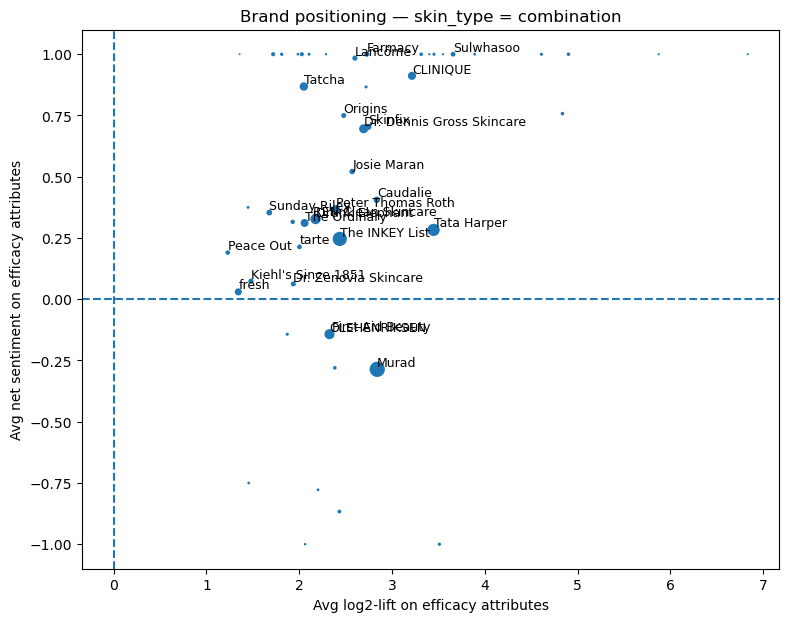

,brand,x_mean_log2lift,y_mean_net_sent,size_mentions
34,Paula's Choice,6.833571,1.000000,3.0
9,DAMDAM,5.874936,1.000000,3.0
16,Estée Lauder,4.901738,1.000000,23.0
20,Herbivore,4.837320,0.757576,24.0
3,Benefit Cosmetics,4.610104,1.000000,15.0
2,BeautyBio,3.890690,1.000000,10.0
40,Sulwhasoo,3.658549,1.000000,56.0
41,Summer Fridays,3.548862,1.000000,4.0
22,IT Cosmetics,3.510880,-1.000000,18.0
29,Moon Juice,3.452735,1.000000,15.0


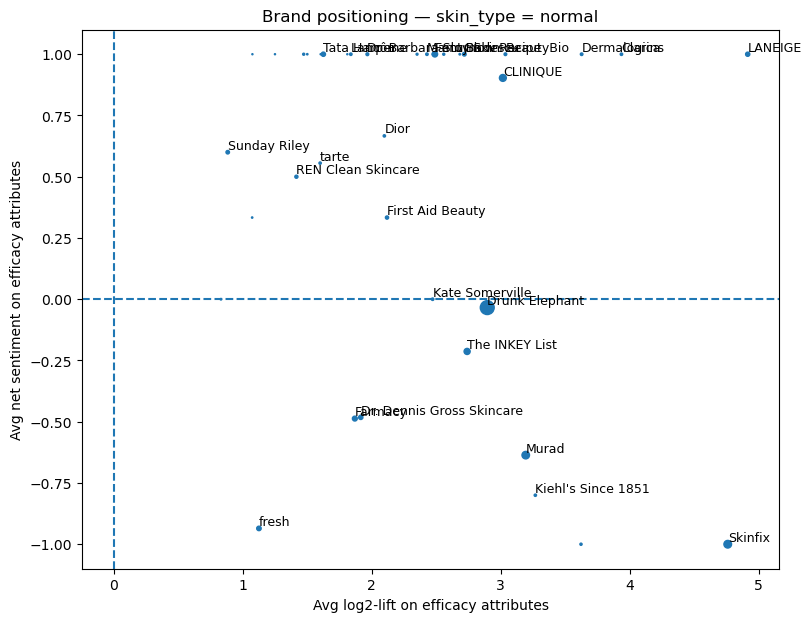

,brand,x_mean_log2lift,y_mean_net_sent,size_mentions
20,LANEIGE,4.916190,1.000000,29.0
28,Skinfix,4.761435,-1.000000,96.0
5,Clarins,3.937259,1.000000,10.0
6,Dermalogica,3.628662,1.000000,11.0
0,Algenist,3.623715,-1.000000,8.0
19,Kiehl's Since 1851,3.269691,-0.800000,9.0
23,Murad,3.195293,-0.636364,93.0
1,BeautyBio,3.037698,1.000000,12.0
4,CLINIQUE,3.017957,0.903226,78.0
11,Drunk Elephant,2.896807,-0.034247,317.0


In [ ]:
for sk in ["oily","dry","combination","normal","sensitive"]:
    if (top_by_skin["skin_type"].astype(str).str.lower()==sk).any():
        brand_positioning_by_skin(top_by_skin, sk)
